In [1]:
# collision_probability.py
# To add a new cell, type '# %%'
# To add a new markdown cell, type '# %% [markdown]'

In [2]:
# Import modules
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path
import math
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import random
import numpy as np


# Collision probability

(*The analysis is based on the reid1979.pdf paper*)

Let us consider a constant collision cross section $\sigma$, if a particle moves with a velocity 
$v$ in time $dt$ it will cover a volume $V=\sigma v dt$. If the gas density is $N$, than in the 
volume will be $N \sigma v dt$ number of particles, that equals the number of collisions in $dt$. 
If we consider $n_0$ identical particles at the starting time $t_0$, moving with velocity $v$, 
than the number of collisions in $dt$ will be:

\begin{equation}
n_{c} = n_0 N \sigma v dt
\end{equation}

and we are left with this number of free (not colided particles).

\begin{equation}
n(t_0 + dt) = n_0 - n_c = n_0 (1 - N \sigma v dt)
\end{equation}

That is to say, the change of the number of free particles in time is:

\begin{equation}
\frac{\mathrm{d} n}{\mathrm{d} t} = -\frac{\mathrm{d} n_c}{\mathrm{d} t} = -n N \sigma v
\end{equation}

If we run this situation for a time $T$ than we will have $n_T$ particles that have free time 
bigger than $T$:

\begin{equation}
\int_{n_0}^{n_T} \frac{1}{n} dn = - N \int_{t_0}^{T} \sigma v dt
\end{equation}

which is:

\begin{equation}
\ln{\left(\frac{n_T}{n_0}\right)} = - N X(T)
\end{equation}

We can say that the probability for a particle to have a collision in time $T$ 
(we denote it by $P$), is the ratio of particles that had a collision $n_0 - n_T$ to 
all particles $n_0$:

\begin{equation}
P = 1 - \frac{n_T}{n_0} = 1 - \exp{\left(-N X(T)\right)}
\end{equation}

## Example 1
 
We run 100k particles, for a single $dt$ in 100 samples. In every timestep the collision 
probability is the same $P=0.1$. The theory says that the most probable number of collisions 
is $N_{coll} = 100k*0.1 = 10k$

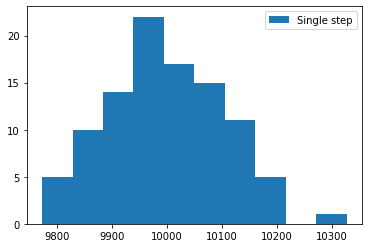

In [3]:
# Run 100 times 100k particles
P = 0.1
run_cnt = 100
part_cnt = 100_000
h1 = []
for _ in range(run_cnt):
    coll_cnt = 0
    for _ in range(part_cnt):
        if random.random() < P:
            coll_cnt += 1
    h1.append(coll_cnt)

plt.hist(h1, label="Single step")
plt.legend()


## Example 2

Lets run the following situation: we run for 10 timesteps and in each timestep there is 10 times 
less probability for collision. There are two things that we can count, particles that collided 
and number of collisions. If the same particle collided more than once, particle collision will 
count this as 1. 

In this setup:

- If we count the number of collisions, we will have same situation as in example 1.
- If we count particles that collided we will have a different, lower count, than particles 
  that collided in example 1.

Particle collisions in accumulation of 10 steps.


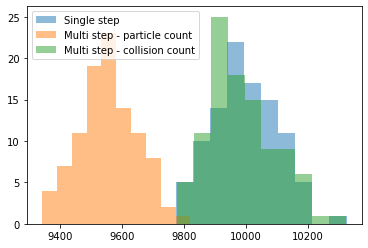

In [4]:
# Run 10 timesteps for 100 samples of 100k particles
P = 0.1
run_cnt = 100
part_cnt = 100_000
step_cnt = 10
h2a = []
h2b = []
for _ in range(run_cnt):
    part_coll_cnt = 0
    coll_cnt = 0
    for _ in range(step_cnt):
        for _ in range(0, part_cnt):
            if random.random() < P/step_cnt:
                coll_cnt += 1
        # We offset the counter of particle collisions
        # so we don't check collided particles
        for _ in range(part_coll_cnt, part_cnt):
            if random.random() < P/step_cnt:
                part_coll_cnt += 1
    h2a.append(part_coll_cnt)
    h2b.append(coll_cnt)

print(f"Particle collisions in accumulation of {step_cnt} steps.")
plt.hist(h1, label="Single step", alpha=0.5)
plt.hist(h2a, label="Multi step - particle count", alpha=0.5)
plt.hist(h2b, label="Multi step - collision count", alpha=0.5)
plt.legend()


## Example 3

Now we try to calculate by theory the number of particles that collided. In other words, we set 
the probability for collision at a value so that the number of particles that collided is the 
same as in example 1.

Collisions in accumulation of 10 steps, with real probability.


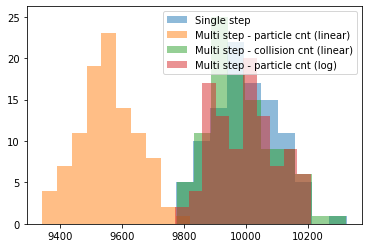

In [5]:
# Run example 2 with different probability
P = 0.1
run_cnt = 100
part_cnt = 100_000
step_cnt = 10
C = math.log(1.0/(1.0 - P))
PC = 1.0 - math.exp(-C/step_cnt)
h3 = []
for _ in range(run_cnt):
    part_coll_cnt = 0
    for _ in range(step_cnt):
        for _ in range(part_coll_cnt, part_cnt):
            if random.random() < PC:
                part_coll_cnt += 1
    h3.append(part_coll_cnt)

print(f"Collisions in accumulation of {step_cnt} steps, with real probability.")
plt.hist(h1, label="Single step", alpha=0.5)
plt.hist(h2a, label="Multi step - particle cnt (linear)", alpha=0.5)
plt.hist(h2b, label="Multi step - collision cnt (linear)", alpha=0.5)
plt.hist(h3, label="Multi step - particle cnt (log)", alpha=0.5)
plt.legend()


## Collision probability as a function of time

This is the probability for a particle to collide from zero to a time which is given in number
of $dt$.

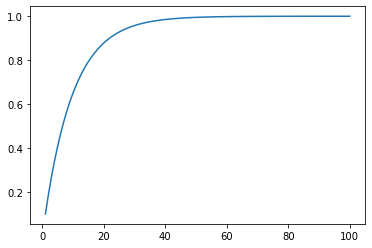

In [6]:
# Draw collision probability
x=[i+1 for i in range(run_cnt)]
y=[1.0 - math.exp(-C*xi) for xi in x]

plt.plot(x, y, label="Probabilty")


Lets caclculate probabilities in the given three cases before. 
- Probability for a collisiont in a single $dt$.
- Probability for collision in 10 steps step with linear dependence (number of collisions).
- Probability for collision in 10 steps step with log dependence 
  (number of particles that collided).

In [7]:
# Calculate probabilites
P = 0.01
step_cnt = 10
print(f"Single step probability: P = {P}")
print(f"Multi step linear probability: PL = {P*step_cnt}")
print(f"Multi step real probability: PC = {1.0 - math.exp(-math.log(1.0/(1.0 - P))*step_cnt)}")


Single step probability: P = 0.01
Multi step linear probability: PL = 0.1
Multi step real probability: PC = 0.09561792499119615


We conclude that if we have a small probability for collision per $dt$, then we can approximate 
the real probability with a linear one.

\begin{equation}
P = 1 - \frac{n_T}{n_0} = 1 - \exp{\left(-N X(T)\right)} \approx 1 - (1 + N X(T)) = N X(T)
\end{equation}

For example if we have a probability for collision per $dt$ of $1\%$, then for duration ten times 
longer we can approximately say that there will be $10\%$ collisions (the correct value is closer 
to $9.562\%$).

## Velocity dependent cross section

We consider cross section to be dependent of the projectile energy $\varepsilon$, that is 
$\sigma(\varepsilon)$. This means that we must calculate the probability for collision in every 
timestep. We consider that the timestep is sufficiently small during which the energy can be taken 
to have a constant value. Let us as an example set the most simple, linear, functional dependence 
of the cross section:

\begin{equation}
\sigma(\varepsilon) = S\varepsilon = Kv^2
\end{equation}

The probability for collision at speed $v$ in a small $\Delta t$ is:

\begin{equation}
P(v) = 1 - \exp{\left(-N \sigma(v) v \Delta t\right)}
\end{equation}

Often used technique to reduce the number of calculation is the null-collision. We add 
null-collision $\sigma_n$ cross section that has the property that the total cross section is:

\begin{equation}
\sigma_t(v) = \sigma(v) + \sigma_n(v) = Cv^{-1}
\end{equation}

This gives a constant probability of collisions:

\begin{equation}
P(v) = 1 - \exp{\left(-N \sigma_t(v) v \Delta t\right)} =  1 - \exp{ \left( -N C \Delta t \right) }
\end{equation}

Next we calculate the null-collision's coefficient.

\begin{equation}
\sigma_n(v) = Cv^{-1} - Kv^2
\end{equation}

In the desired range of speed (we take speeds up to $V_{max}$) we find the maximum value of the 
cross section. For our simple case it is at the maximum value of the range 
$\sigma_{max} = \sigma(V_{max})$. At this value the null-collision we set to be zero:

\begin{equation}
\sigma_n(V_{max}) = CV_{max}^{-1} - KV_{max}^2 = 0 \,\, \Rightarrow \,\, C = KV_{max}^3

\end{equation}

Cross section, null cross with max at Vmax=1000.


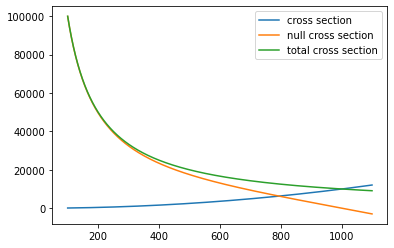

In [8]:
# Calculate null cross section
K = 0.01
Vmax = 1000
C = K * Vmax**3
v=[i+100 for i in range(Vmax)]
s=[0.01*(vi*vi) for vi in v]
sn=[C/vi - K*vi**2 for vi in v]
st=[s[i] + sn[i] for i in range(Vmax)]
p=[1.0 - math.exp(-1.0e-9*s[i]*v[i]) for i in range(Vmax)]
pt=[1.0 - math.exp(-1.0e-9*st[i]*v[i]) for i in range(Vmax)]

print("Cross section, null cross with max at Vmax=1000.")
plt.plot(v, s, label="cross section")
plt.plot(v, sn, label="null cross section")
plt.plot(v, st, label="total cross section")
plt.legend()



Probability of collision.


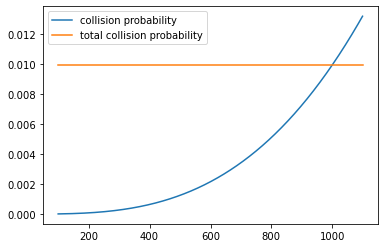

In [9]:
# Collision probability
print("Probability of collision.")
plt.plot(v, p, label="collision probability")
plt.plot(v, pt, label="total collision probability")
plt.legend()


## Time of collision

Since we have a total collision that gives a constant collision probability for any velocity, 
we can easily estimate the time of collision for every particle much easily. Since there is no 
dependence on the state of the particle, the time of collision is selected only with the use of a 
random number generator. In the case of constant collision probability, the probability changes 
only with passage of on time. As time passes the probability for a collision increases.

Take M number of particles at starting time, and lets say we want to calculate how many of them 
will collide from a time $t$ to $t+dt$. At time $t$ we have $M(1-P(t))$ available particles for 
collision, and only $P(dt)$ fraction will collide during that small interval. We can say that the
 number of particles that collide is:

\begin{equation}
M_{coll} = M \left(1-P(t) \right) \cdot P(dt) = M \exp{ \left( -N C t \right) } \cdot \left( 1 - \exp{ \left( -N C  dt \right)} \right)
\end{equation}

This also means that the probability that a particle will have a time of collision of $t$ is:

\begin{equation}
\frac{M_{coll}}{M} = \exp{ \left( -N C t \right) } \cdot \left( 1 - \exp{ \left( -N C  dt \right)} \right)
\end{equation}

Lets choose a different approach to determining collisions. Lets say that we will find the 
collision time, and collide at the given timestamp. We choose collision time by sampling random 
numbers with the probability distribution $p(t) = \exp(-NCt)$. Explanation how is this done is 
given in the section:
[Sampling random number from a distribution](sampling-random-number-from-a-distribution).

### Example 1

Lets take the probability in single $dt$ is 1%, and $dt = 10ns$.

\begin{equation}
P(dt) = 1 - \exp{\left(-N C dt \right)} \, \, \Rightarrow \, \, N C  = \frac{-\ln(1 - P)}{dt}
\end{equation}

The plot of the probability of collision time is:

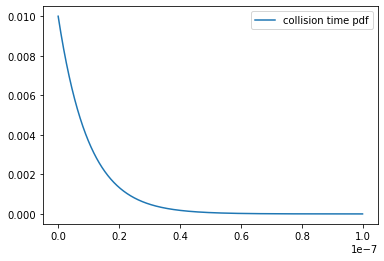

In [10]:
P = 0.01
dt = 1.0e-10
NC = -math.log(1.0 - P)/dt
def col_time_prob(t):
    global dt
    return math.exp(-NC*t)*(1.0 - math.exp(-NC*dt))

t_li = [i*dt for i in range(0, 1000)]
p_li = [col_time_prob(t) for t in t_li]

plt.plot(t_li, p_li, label="collision time pdf")
plt.legend()


In order to create a sampler for this distribution, first we integrate the function
to get cumulative distribution function (cdf). The cumulative distribution tells us what is the 
probability for a particle to have a collision time from zero up to some time $t$.

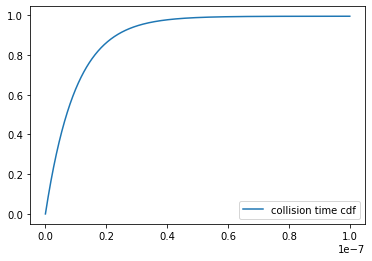

In [11]:
# Calculate cdf
LEN = len(t_li)
pint_li = [0]*LEN
idpint_li = [0]*LEN
psum = 0
for i in range(1, LEN):
    psum += 0.5*(p_li[i-1]+p_li[i])
    pint_li[i] = psum
    idpint_li[i-1] = 1.0/(pint_li[i] - pint_li[i-1])

plt.plot(t_li, pint_li, label="collision time cdf")
plt.legend()


After calculating cdf, we make LUT vector for easier interpolation. We use the characteristic
of the cdf that is monotonicaly rising and split its domain from $y_{min}$ to $y_{max}$ to 
equal pieces. Then for every piece we calculate the position on the x axis and fill the LUT table.

In [12]:
# Create LUT table
dlut = (pint_li[-1] - pint_li[0]) / LEN
idlut = 1.0 / dlut
lutoff = pint_li[0]
lut_li = [-1]*LEN
for i in range(LEN):
    pint = lutoff + i*dlut
    for j in range(LEN - 1):
        if pint_li[j] <= pint < pint_li[j+1]:
            # ex. LEN = 1000, i = 250, pint = 0.25, j = 456 
            # ===> lut_li[250] = 456
            lut_li[i] = j
            break
    if lut_li[i] == -1:
        lut_li[i] = LEN - 1


Lets examine if the random number returns correct probability distiribuition for the 
collision time. We choose 100k collision times, and the histogram shows how many times 
we have hit a collision time in a single $dt$ (we achieve this with setting ``bins = 1000``
so every $dt$ in the histogram has same value as $dt$ in our algorithm).

In the end we have to scale hits to the number of samples in order to get probability value.

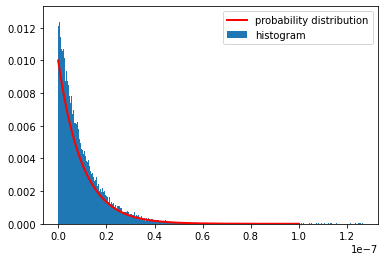

In [13]:
# Create function for interpolation from LUT
def get_from_lut(y, lut_li, x_li, yint_li, idyint_li):
    i = int((y - lutoff)*idlut) 
    if i >= len(lut_li) - 1:
        i = len(lut_li) - 1
    j = lut_li[i]
    # For faster code: idy_li[j] = 1.0/(y_li[j+1] - y_li[j])
    return (x_li[j] + (x_li[j+1] - x_li[j])*(y - yint_li[j])*idyint_li[j])


h=[]
num_samples = 100000
for _ in range(num_samples):
    p = random.random()
    t = get_from_lut(p, lut_li, t_li, pint_li, idpint_li)
    h.append(t)

factor = 1.0 / num_samples
plt.hist(h, label="histogram", bins=LEN, density=False, weights=factor*np.ones_like(h))
plt.plot(t_li, p_li, label="probability distribution", lw=2, color='red')
plt.legend()



## Sampling random number from a distribution

To sample random number with a given distribution $f(x)$, we use the following technique. First we integrate the distribution function

\begin{equation}
F(x) = \int_{-\infty}^{+\infty} f(x) dx
\end{equation}

Then we generate uniform number in the range from zero to one, $p$, and we derive $x$ by interpolation as the value that gives the probability $F(x) = p$.

If we have the following function

\begin{equation}
f(x) = Ax^3 + Bx^2 + Cx + D
\end{equation}

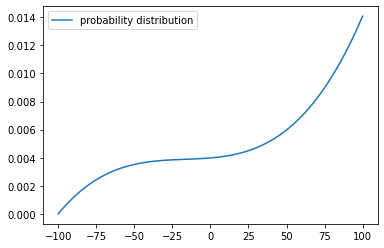

In [14]:
dx = 0.1
x_li = [x*dx for x in range(-1000, 1000)]
A = 0.0002/32620.711465
B = 0.01/32620.711465
C = 0.3/32620.711465
D = 130/32620.711465

def f_func(x):
    return A*x**3 + B*x**2 + C*x + D 

f_li = [f_func(x) for x in x_li]
LEN = len(x_li)
fint_li = [0]*LEN
ifint_li = [0]*LEN
fsum = 0
for i in range(1, LEN):
    fsum += dx*0.5*(f_li[i-1]+f_li[i])
    fint_li[i] = fsum
    ii = int(fsum*LEN) - 1
    ifint_li[ii] = i - 1

for i in range(1, LEN):
    if ifint_li[i] == 0:
        ifint_li[i] = ifint_li[i-1]
plt.plot(x_li, f_li, label="probability distribution")
plt.legend()



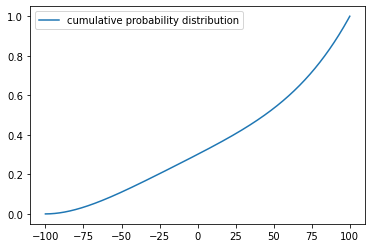

In [15]:
plt.plot(x_li, fint_li, label="cumulative probability distribution")
plt.legend()



In [16]:
h=[]
for _ in range(10000):
    p = random.random()
    ii = int(p*LEN) - 1
    i = ifint_li[ii]
    x = x_li[i] + dx*(p - fint_li[i])/(fint_li[i+1] - fint_li[i])
    h.append(x)



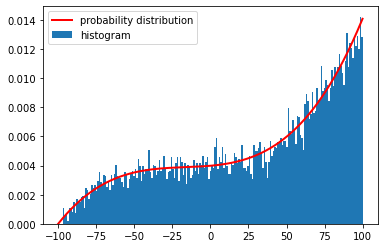

In [17]:
plt.hist(h, label="histogram", bins=200, density=True)
plt.plot(x_li, f_li, label="probability distribution", lw=2, color='red')
plt.legend()



## Collisions from chosing time of collision

Ok, we get back to our problem. Let us collide particle by choosing time of collision
from the probability distribution that we calculated.
